# Who would a family hire instead of me?

**Business question:** In my best-fit areas (Alameda and the Oakland hills), who are the competitors, what do they offer and charge, and what do I offer that they do not?

**Why it matters:** The earlier notebooks measured demand: who needs help and who can pay. This one looks at supply. It tells me what to say in my pitch and whether my rate and minimum visit hold up.

**Data:** This is not Census data. On October 3, 2026 I read one public web page for each of 15 home care agencies that say they serve Alameda or Oakland, and two Care.com listing pages. What each page says is recorded by hand in `data/competitors.csv` and `data/care_com_listings.csv`, with the web address of every page.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 60)

agencies = pd.read_csv("../data/competitors.csv")
listings = pd.read_csv("../data/care_com_listings.csv")
N = len(agencies)
print(N, "agencies and", len(listings), "Care.com listing pages loaded")
agencies[["name", "areas_listed"]]

15 agencies and 2 Care.com listing pages loaded


,name,areas_listed
0,Visiting Angels Alameda,"Alameda, Oakland, Piedmont, Berkeley, Castro Valley"
1,Senior Helpers of Alameda,"Alameda, Castro Valley, San Leandro, Oakland"
2,Seniors Helping Seniors Alameda,"Oakland, Alameda, Piedmont, Montclair"
3,Right at Home Alameda County,Oakland and Alameda County
4,Premier Homecare Angels,Alameda
5,AEC Home Care,"Alameda, Oakland, San Leandro, Castro Valley, Hayward, P..."
6,Alice Home Care,"Alameda and Contra Costa counties, including Oakland, Be..."
7,Beacon Home Care,"Oakland, Oakland Hills, Piedmont, Montclair, Alameda, Be..."
8,Hillendale Home Care,Montclair and Alameda County
9,J&M Homecare Services,Oakland and other East Bay cities


## 1. What the agencies advertise

For each agency I recorded "yes" only when the page I read says it. "Not stated" means the page does not mention it. The agency may still offer it, so read every count as **what they advertise**, not what they do.

In [2]:
FEATURES = {
    "hands_on_care":          "Hands-on personal care",
    "errands":                "Errands and shopping",
    "rides_for_clients":      "Rides for clients (I do not offer this)",
    "medication_reminders":   "Medication reminders",
    "no_minimum":             "No minimum visit length",
    "spanish_speaking":       "Spanish-speaking caregivers",
    "tech_help":              "Help with technology",
    "paperwork_help":         "Help with paperwork, mail or bills",
    "publishes_hourly_price": "Hourly price shown on the website",
}
# The things I offer that could set me apart
MY_EDGE = ["spanish_speaking", "tech_help", "paperwork_help", "publishes_hourly_price"]

agencies["no_minimum"] = agencies["minimum_visit"].eq("No minimum").map({True: "yes", False: "not stated"})
counts = pd.DataFrame({"what": FEATURES, "agencies": {k: int((agencies[k] == "yes").sum()) for k in FEATURES}})
counts["share"] = counts["agencies"] / N
counts["my_edge"] = counts.index.isin(MY_EDGE)
counts = counts.sort_values("agencies", ascending=False)

for _, r in counts.iterrows():
    print(f"{r['agencies']:2d} of {N}  {r['what']}")

14 of 15  Hands-on personal care
10 of 15  Errands and shopping
10 of 15  Rides for clients (I do not offer this)
10 of 15  Medication reminders
 2 of 15  No minimum visit length
 1 of 15  Spanish-speaking caregivers
 0 of 15  Help with technology
 0 of 15  Help with paperwork, mail or bills
 0 of 15  Hourly price shown on the website


## 2. Independent helpers on Care.com

Agencies are one kind of competitor. Independent helpers are the other, and they are closer to what I am. These numbers come from the first 20 profiles shown on each listing page, as summarized by a reading tool, so treat them as rough.

In [3]:
for _, r in listings.iterrows():
    n = r["profiles_read"]
    print(f"{r['listing']}: {r['helpers_listed']} listed, average ${r['average_hourly_rate']} an hour")
    print(f"   Of the first {n} profiles: {r['mention_hands_on_care']} mention hands-on care, {r['mention_driving']} driving, "
          f"{r['mention_paperwork_help']} paperwork or admin help, {r['mention_tech_help']} tech help, {r['mention_spanish']} Spanish")

Care.com personal assistants, Alameda: 60 listed, average $33 an hour
   Of the first 20 profiles: 10 mention hands-on care, 11 driving, 3 paperwork or admin help, 0 tech help, 0 Spanish
Care.com home care helpers, Oakland: 60 listed, average $28 an hour
   Of the first 20 profiles: 18 mention hands-on care, 14 driving, 4 paperwork or admin help, 0 tech help, 0 Spanish


## 3. How my offer compares

My rate is &#36;35 an hour with a 4-hour minimum. Two price points from the market research report: agencies in Alameda County charge about &#36;38 to &#36;43 an hour (a directory figure, undated), and Care.com helpers in these cities post about &#36;28 to &#36;33 an hour.

In [4]:
edge = counts[counts["my_edge"]]
print("What I offer that few agencies advertise:")
for _, r in edge.iterrows():
    print(f"   {r['what']}: {r['agencies']} of {N} agencies")

print("\nWhere competitors advertise more than I offer:")
rides = counts.loc["rides_for_clients"]
print(f"   Rides for clients: {rides['agencies']} of {N} agencies. I do not drive clients.")
nomin = counts.loc["no_minimum"]
print(f"   No minimum visit: {nomin['agencies']} of {N} agencies say so. I have a 4-hour minimum.")

print("\nPrice:")
print(f"   {counts.loc['publishes_hourly_price', 'agencies']} of {N} agencies show an hourly price on the page I read.")
print(f"   Care.com helpers post an average of ${listings['average_hourly_rate'].min()} to ${listings['average_hourly_rate'].max()} an hour, below my $35.")

What I offer that few agencies advertise:
   Spanish-speaking caregivers: 1 of 15 agencies
   Help with technology: 0 of 15 agencies
   Help with paperwork, mail or bills: 0 of 15 agencies
   Hourly price shown on the website: 0 of 15 agencies

Where competitors advertise more than I offer:
   Rides for clients: 10 of 15 agencies. I do not drive clients.
   No minimum visit: 2 of 15 agencies say so. I have a 4-hour minimum.

Price:
   0 of 15 agencies show an hourly price on the page I read.
   Care.com helpers post an average of $28 to $33 an hour, below my $35.


## 4. Chart: what 15 agencies advertise

Each bar is the number of agencies whose page mentions that item. Blue bars are things I offer that few of them advertise.

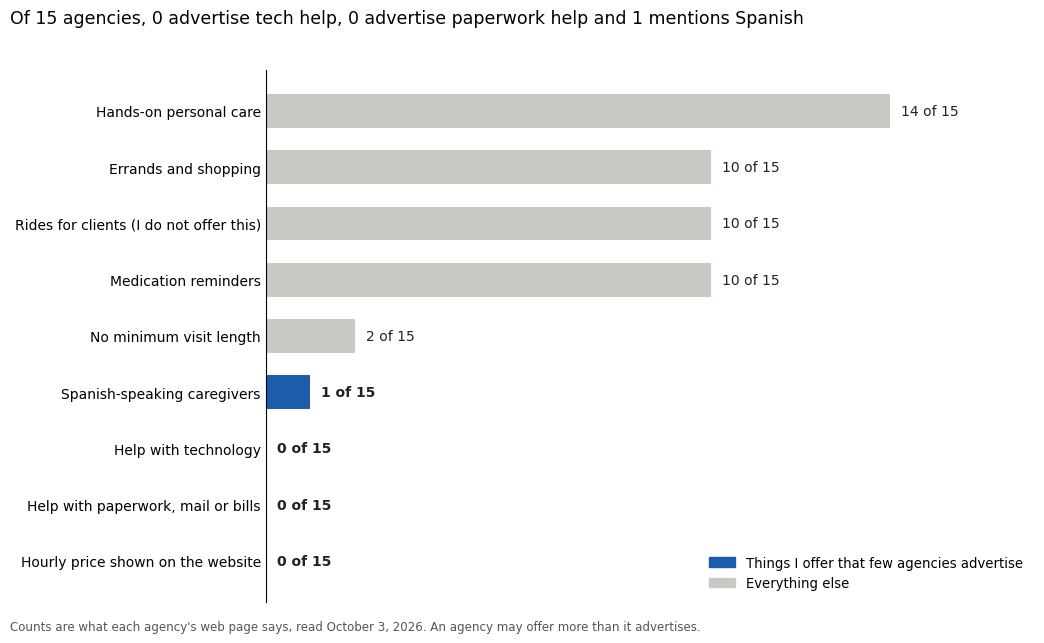

In [5]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

ypos = list(range(len(counts)))[::-1]   # first row at the top
BLUE, GRAY = "#1c5cab", "#c9c9c4"

fig, ax = plt.subplots(figsize=(10.5, 0.5 * len(counts) + 1.9))
ax.barh(ypos, counts["agencies"], color=[BLUE if e else GRAY for e in counts["my_edge"]], height=0.6)
for y, (_, r) in zip(ypos, counts.iterrows()):
    ax.text(r["agencies"] + 0.25, y, f"{r['agencies']} of {N}", va="center", fontsize=10, color="#222222",
            fontweight="bold" if r["my_edge"] else "normal")
ax.set_yticks(ypos)
ax.set_yticklabels(counts["what"], fontsize=10)
ax.set_xlim(0, N * 1.15)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=GRAY)]
ax.legend(handles, ["Things I offer that few agencies advertise", "Everything else"],
          loc="lower right", frameon=False, fontsize=9.5)
tech, paper, spanish = (counts.loc[k, "agencies"] for k in ["tech_help", "paperwork_help", "spanish_speaking"])
fig.suptitle(f"Of {N} agencies, {tech} advertise tech help, {paper} advertise paperwork help and {spanish} mentions Spanish",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, "Counts are what each agency's web page says, read October 3, 2026. An agency may offer more than it advertises.",
         fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(f"{OUT}/competitors.png", dpi=150)
counts.round(3).to_csv(f"{OUT}/competitors_summary.csv")
plt.show()

## 5. What I decided

- **What I lead with in my pitch:** One reliable person for hands-on care plus help with technology and paperwork, bilingual in English and Spanish, and a registered Home Care Aide.
- **How I answer "do you drive?":** I do not drive clients in my own vehicle. The client or a family member can drive, or I come along by rideshare, taxi, transit or paratransit.
- **Keep the 4-hour minimum?** Yes. Only 2 of the 15 agencies advertise no minimum. I will add a visit every other week for tighter budgets.
- **Show my price on my website?** No. I will quote my rate privately when someone asks.

### Limits to remember
- I read one page per agency. Other pages on the same site may mention services, prices or languages that this page does not.
- These are 15 agencies that came up in web searches for Alameda and Oakland, not a full list. A directory lists about 180 agencies in Alameda County.
- What an agency advertises is not always what it delivers, and the reverse.
- The Care.com numbers come from the first 20 profiles on each page and were summarized by a tool, not read one by one.
- This shows who the competitors are, not how busy they are or how happy their clients are.